## Anggota Kelompok
1. Fanny Widya Cahyani  (24083010045)
2. Izzati Kamila Putri  (24083010059)
3. Adrian Veda Darmawan (24083010090)

# Imports & setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter
import math
from itertools import combinations

%config InlineBackend.figure_format = 'retina'

# Definisi graph

In [2]:
def draw_graph(G, pos, title="Visualisasi Jaringan Sosial",
               node_colors=None, node_sizes=None, edge_colors=None,
               font_color="black", edgecolors=None, linewidths=0.8,
               font_size=8, with_labels=True):
    """
    Fungsi yang diperbaiki untuk menggambar graph dengan layout 'pos'
    dan parameter visualisasi yang fleksibel.
    """
    plt.figure(figsize=(13, 9))

    if node_colors is None:
        node_colors_attr = nx.get_node_attributes(G, "color").values()

        node_colors = list(node_colors_attr) if node_colors_attr else "#A8DADC"

    if edge_colors is None:
        edge_colors_attr = nx.get_edge_attributes(G, "color").values()

        edge_colors = list(edge_colors_attr) if edge_colors_attr else "#457B9D"


    if node_sizes is None:
        node_sizes = 200

    if edgecolors is None:
        edgecolors = "black"

    nx.draw(
        G,
        pos,
        with_labels=with_labels,
        node_size=node_sizes,
        node_color=node_colors,
        edge_color=edge_colors,
        font_size=font_size,
        font_color=font_color,
        linewidths=linewidths,
        edgecolors=edgecolors
    )

    plt.title(title, fontsize=15, fontweight="bold")
    plt.show()

In [3]:
G = nx.Graph()

mahasiswa = [
"Madina", "Maria", "Adinda", "Aquina", "Alimun", "Hizkia", "Raveena",
"Ophyng", "Aisyah", "Febriani", "Amelia", "Via", "Fanny", "Naia",
"Alfani", "Diah", "Kenzy", "Angel", "Maulida", "Izzati", "Auliya",
"Carissa", "Diva", "Erik", "Maya", "Dany", "Gendis", "Wildan", "Esthi",
"Naufal", "Laudya", "Adrian", "Selvy", "Hafiyyan", "Indra", "Yuniar",
"Kiky", "Sofia", "Varid", "Gaitsa"]
G.add_nodes_from(mahasiswa)

sekelompok= [
    ("Raveena", "Amelia"), ("Raveena", "Yuniar"), ("Yuniar", "Amelia"),
    ("Hizkia", "Maria"), ("Hizkia", "Sofia"), ("Sofia", "Maria"),
    ("Naufal", "Laudya"), ("Naufal", "Febriani"), ("Febriani", "Laudya"),
    ("Kenzy", "Wildan"), ("Wildan", "Hafiyyan"), ("Kenzy", "Hafiyyan"),
    ("Alimun", "Dany"), ("Dany", "Indra"), ("Indra", "Alimun"),
    ("Esthi", "Kiky"), ("Kiky", "Selvy"), ("Selvy", "Esthi"),
    ("Adrian", "Izzati"), ("Izzati", "Fanny"), ("Fanny", "Adrian"),
    ("Aquina", "Diva"), ("Diva", "Maya"), ("Maya", "Aquina"),
    ("Diah", "Gendis"), ("Gendis", "Angel"), ("Angel", "Diah"),
    ("Ophyng", "Aisyah"), ("Aisyah", "Naia"), ("Naia", "Ophyng"),
    ("Adinda", "Varid"), ("Varid", "Gaitsa"), ("Gaitsa", "Adinda"),
    ("Auliya", "Carissa"), ("Carissa", "Erik"), ("Erik", "Auliya"),
    ("Madina", "Via"), ("Maulida", "Madina"), ("Via", "Alfani"),
    ("Madina", "Alfani"), ("Maulida", "Via"), ("Maulida", "Alfani")
]
relasi = sekelompok.copy()

def tambah_relasi_dari_array(array):
  for i in range(len(array)):
    for j in range(len(array)-i-1):
      relasi.append((array[i], array[j+i+1]))

akamsi = ["Yuniar", "Via", "Raveena", "Kenzy", "Esthi", "Alimun", "Amelia",
          "Indra", "Madina", "Maulida", "Kiky", "Varid"]
jabodetabek = ["Sofia", "Maria", "Gaitsa", "Aisyah"]
tambah_relasi_dari_array(jabodetabek)
platP= ["Angel", "Yuniar"]; tambah_relasi_dari_array(platP)
platS= ["Naia", "Izzati"]; tambah_relasi_dari_array(platS)
platM= ["Dany", "Alimun"]; tambah_relasi_dari_array(platM)
platN= ["Amelia", "Alfani"]; tambah_relasi_dari_array(platN)
platAx= ["Adrian", "Raveena", "Selvy", "Fanny"]; tambah_relasi_dari_array(platAx)
sekos= ["Aisyah", "Naia"]; tambah_relasi_dari_array(sekos)
himasada= ["Dany", "Amelia", "Yuniar", "Kiky", "Esthi", "Raveena", "Naia",
           "Wildan", "Selvy", "Via", "Madina", "Alfani", "Maulida"]
tambah_relasi_dari_array(himasada)
BEMfakultas = ["Indra", "Hafiyyan", "Varid", "Carissa", "Raveena"]; tambah_relasi_dari_array(BEMfakultas)
warkopbening = ["Raveena", "Yuniar", "Wildan", "Dany", "Maulida", "Izzati"]; tambah_relasi_dari_array(warkopbening)
skincaredanmakeup = ["Hizkia", "Kiky", "Yuniar", "Raveena", "Sofia", "Amelia"]; tambah_relasi_dari_array(skincaredanmakeup)
kacamata = ["Adrian", "Fanny", "Izzati", "Hizkia", "Maria", "Naia", "Madina", "Maulida", "Via", "Varid", "Aquina", "Alimun", "Indra"]; tambah_relasi_dari_array(kacamata)
luarpulaujawa = ["Febriani", "Ophyng", "Laudya"]; tambah_relasi_dari_array(luarpulaujawa)

G.add_edges_from(relasi, color='red')
pos = nx.spring_layout(G, seed=42)

In [4]:
relasi

[('Raveena', 'Amelia'),
 ('Raveena', 'Yuniar'),
 ('Yuniar', 'Amelia'),
 ('Hizkia', 'Maria'),
 ('Hizkia', 'Sofia'),
 ('Sofia', 'Maria'),
 ('Naufal', 'Laudya'),
 ('Naufal', 'Febriani'),
 ('Febriani', 'Laudya'),
 ('Kenzy', 'Wildan'),
 ('Wildan', 'Hafiyyan'),
 ('Kenzy', 'Hafiyyan'),
 ('Alimun', 'Dany'),
 ('Dany', 'Indra'),
 ('Indra', 'Alimun'),
 ('Esthi', 'Kiky'),
 ('Kiky', 'Selvy'),
 ('Selvy', 'Esthi'),
 ('Adrian', 'Izzati'),
 ('Izzati', 'Fanny'),
 ('Fanny', 'Adrian'),
 ('Aquina', 'Diva'),
 ('Diva', 'Maya'),
 ('Maya', 'Aquina'),
 ('Diah', 'Gendis'),
 ('Gendis', 'Angel'),
 ('Angel', 'Diah'),
 ('Ophyng', 'Aisyah'),
 ('Aisyah', 'Naia'),
 ('Naia', 'Ophyng'),
 ('Adinda', 'Varid'),
 ('Varid', 'Gaitsa'),
 ('Gaitsa', 'Adinda'),
 ('Auliya', 'Carissa'),
 ('Carissa', 'Erik'),
 ('Erik', 'Auliya'),
 ('Madina', 'Via'),
 ('Maulida', 'Madina'),
 ('Via', 'Alfani'),
 ('Madina', 'Alfani'),
 ('Maulida', 'Via'),
 ('Maulida', 'Alfani'),
 ('Sofia', 'Maria'),
 ('Sofia', 'Gaitsa'),
 ('Sofia', 'Aisyah'),
 ('Maria'

# 1. Cari 3 orang yang konektivitasnya paling banyak

In [5]:
degrees = nx.degree(G)
degrees

DegreeView({'Madina': 21, 'Maria': 15, 'Adinda': 2, 'Aquina': 14, 'Alimun': 13, 'Hizkia': 17, 'Raveena': 21, 'Ophyng': 4, 'Aisyah': 5, 'Febriani': 3, 'Amelia': 14, 'Via': 21, 'Fanny': 14, 'Naia': 23, 'Alfani': 12, 'Diah': 2, 'Kenzy': 2, 'Angel': 3, 'Maulida': 21, 'Izzati': 16, 'Auliya': 2, 'Carissa': 6, 'Diva': 2, 'Erik': 2, 'Maya': 2, 'Dany': 15, 'Gendis': 2, 'Wildan': 15, 'Esthi': 12, 'Naufal': 2, 'Laudya': 3, 'Adrian': 14, 'Selvy': 14, 'Hafiyyan': 6, 'Indra': 16, 'Yuniar': 16, 'Kiky': 14, 'Sofia': 8, 'Varid': 17, 'Gaitsa': 5})

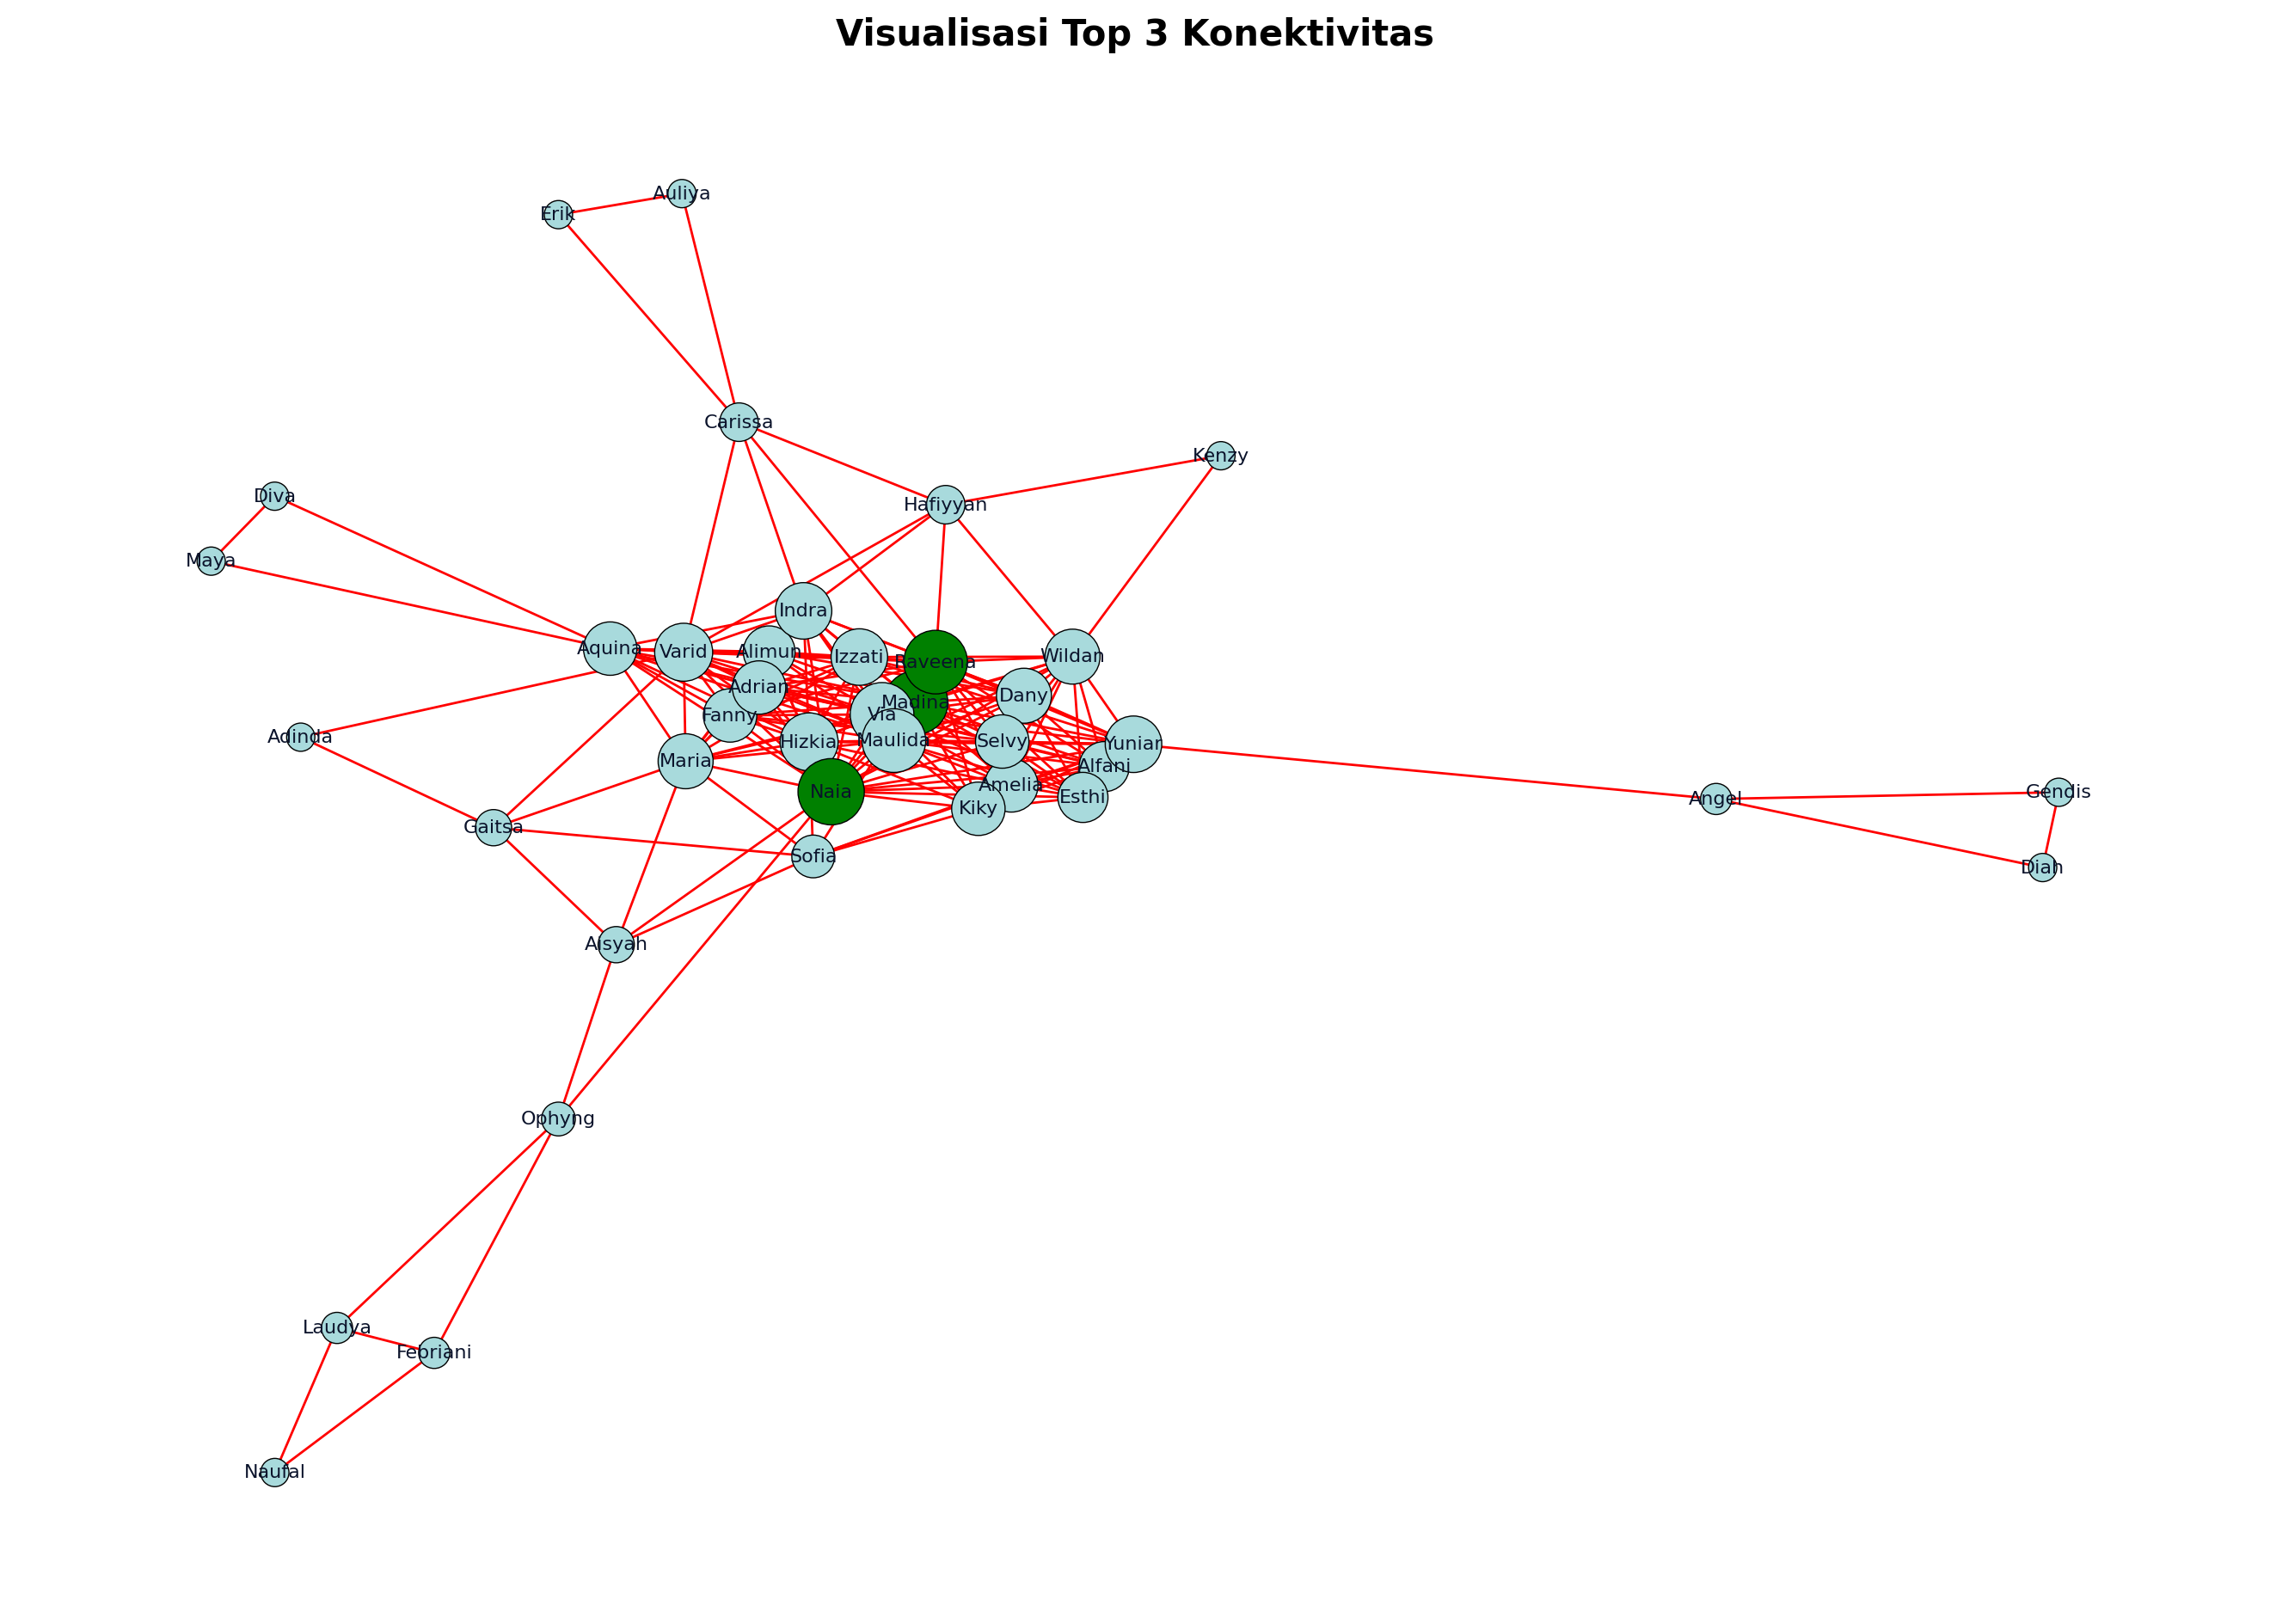

In [6]:
degree_dict = dict(G.degree())
top3 = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:3]

COLOR_CFG = {
    "top3": "green",
    "node": "#A8DADC",
    "edge": "red",
    "label": "#0B132B"
}

node_colors_list = [COLOR_CFG["top3"] if n in [x[0] for x in top3] else COLOR_CFG["node"] for n in G.nodes()]
node_sizes_list = [80 + degree_dict[n]*30 for n in G.nodes()]

draw_graph(
    G,
    pos,
    title="Visualisasi Top 3 Konektivitas",
    node_colors=node_colors_list,
    node_sizes=node_sizes_list,
    edge_colors=COLOR_CFG["edge"],
    font_color=COLOR_CFG["label"],
    linewidths=0.5,
    edgecolors="black"
)

degrees = nx.degree(G)
sorted_degrees = sorted(degrees, key=lambda x: x[1], reverse=True)

Visualisasi di atas menggambarkan jaringan sosial mahasiswa kelas Matematika Diskrit, di mana setiap titik merepresentasikan individu dan setiap garis menunjukkan hubungan pertemanan. Tiga titik berwarna hijau menandakan tiga mahasiswa dengan konektivitas tertinggi, yaitu Raveena, Maulida, dan Naia. Posisi mereka yang berada di pusat jaringan menegaskan peran penting sebagai penghubung antar kelompok sekaligus penjaga kelancaran komunikasi di dalam kelas. Sementara itu, mahasiswa di bagian tepi memiliki relasi yang lebih sedikit, namun tetap menjadi bagian dari ekosistem sosial yang aktif dan saling terhubung. Secara keseluruhan, jaringan ini memperlihatkan pola interaksi yang beragam dan hidup di antara para mahasiswa.

In [7]:
sorted_degrees = sorted(degrees, key=lambda x: x[1], reverse=True)
print("Top 10 mahasiswa dengan relasi terbanyak")
for i in range(10):
  nomor = i+1
  print(f"{nomor}. {sorted_degrees[i][0]} dengan total relasi {sorted_degrees[i][1]} MAHASISWA!!!1!!1")
print()
print("Top 10 mahasiswa dengan relasi tersedikit")
for i in range(10):
  nomor = i+1
  print(f"{nomor}. {sorted_degrees[-i-1][0]} dengan total relasi... {sorted_degrees[-i-1][1]} mahasiswa???")

Top 10 mahasiswa dengan relasi terbanyak
1. Naia dengan total relasi 23 MAHASISWA!!!1!!1
2. Madina dengan total relasi 21 MAHASISWA!!!1!!1
3. Raveena dengan total relasi 21 MAHASISWA!!!1!!1
4. Via dengan total relasi 21 MAHASISWA!!!1!!1
5. Maulida dengan total relasi 21 MAHASISWA!!!1!!1
6. Hizkia dengan total relasi 17 MAHASISWA!!!1!!1
7. Varid dengan total relasi 17 MAHASISWA!!!1!!1
8. Izzati dengan total relasi 16 MAHASISWA!!!1!!1
9. Indra dengan total relasi 16 MAHASISWA!!!1!!1
10. Yuniar dengan total relasi 16 MAHASISWA!!!1!!1

Top 10 mahasiswa dengan relasi tersedikit
1. Naufal dengan total relasi... 2 mahasiswa???
2. Gendis dengan total relasi... 2 mahasiswa???
3. Maya dengan total relasi... 2 mahasiswa???
4. Erik dengan total relasi... 2 mahasiswa???
5. Diva dengan total relasi... 2 mahasiswa???
6. Auliya dengan total relasi... 2 mahasiswa???
7. Kenzy dengan total relasi... 2 mahasiswa???
8. Diah dengan total relasi... 2 mahasiswa???
9. Adinda dengan total relasi... 2 mahasiswa?

Hasil analisis menunjukkan bahwa Naia menempati posisi pertama dengan total 23 relasi, diikuti oleh Madina, Raveena, Via, dan Maulida yang masing-masing memiliki sekitar 21 relasi. Mereka tampaknya menjadi pusat perputaran interaksi di kelas—mungkin karena aktif di berbagai kelompok, atau sekadar punya daya tarik sosial yang tinggi.

Sebaliknya, ada beberapa mahasiswa dengan jumlah relasi yang sangat sedikit, bahkan hanya 2–3 koneksi saja. Agak membingungkan juga ya padahal mereka satu kelas, tapi seolah berada di “ujung” jaringan. Apakah karena kelompoknya kecil, atau memang jarang beririsan dengan lingkaran lain? Fenomena ini menarik untuk ditelusuri lebih lanjut, terutama ketika kita melihat siapa-siapa saja yang ternyata berada paling jauh satu sama lain dalam jaringan sosial kelas ini.

# 2. Pasangan yang Paling Jauh Koneksinya

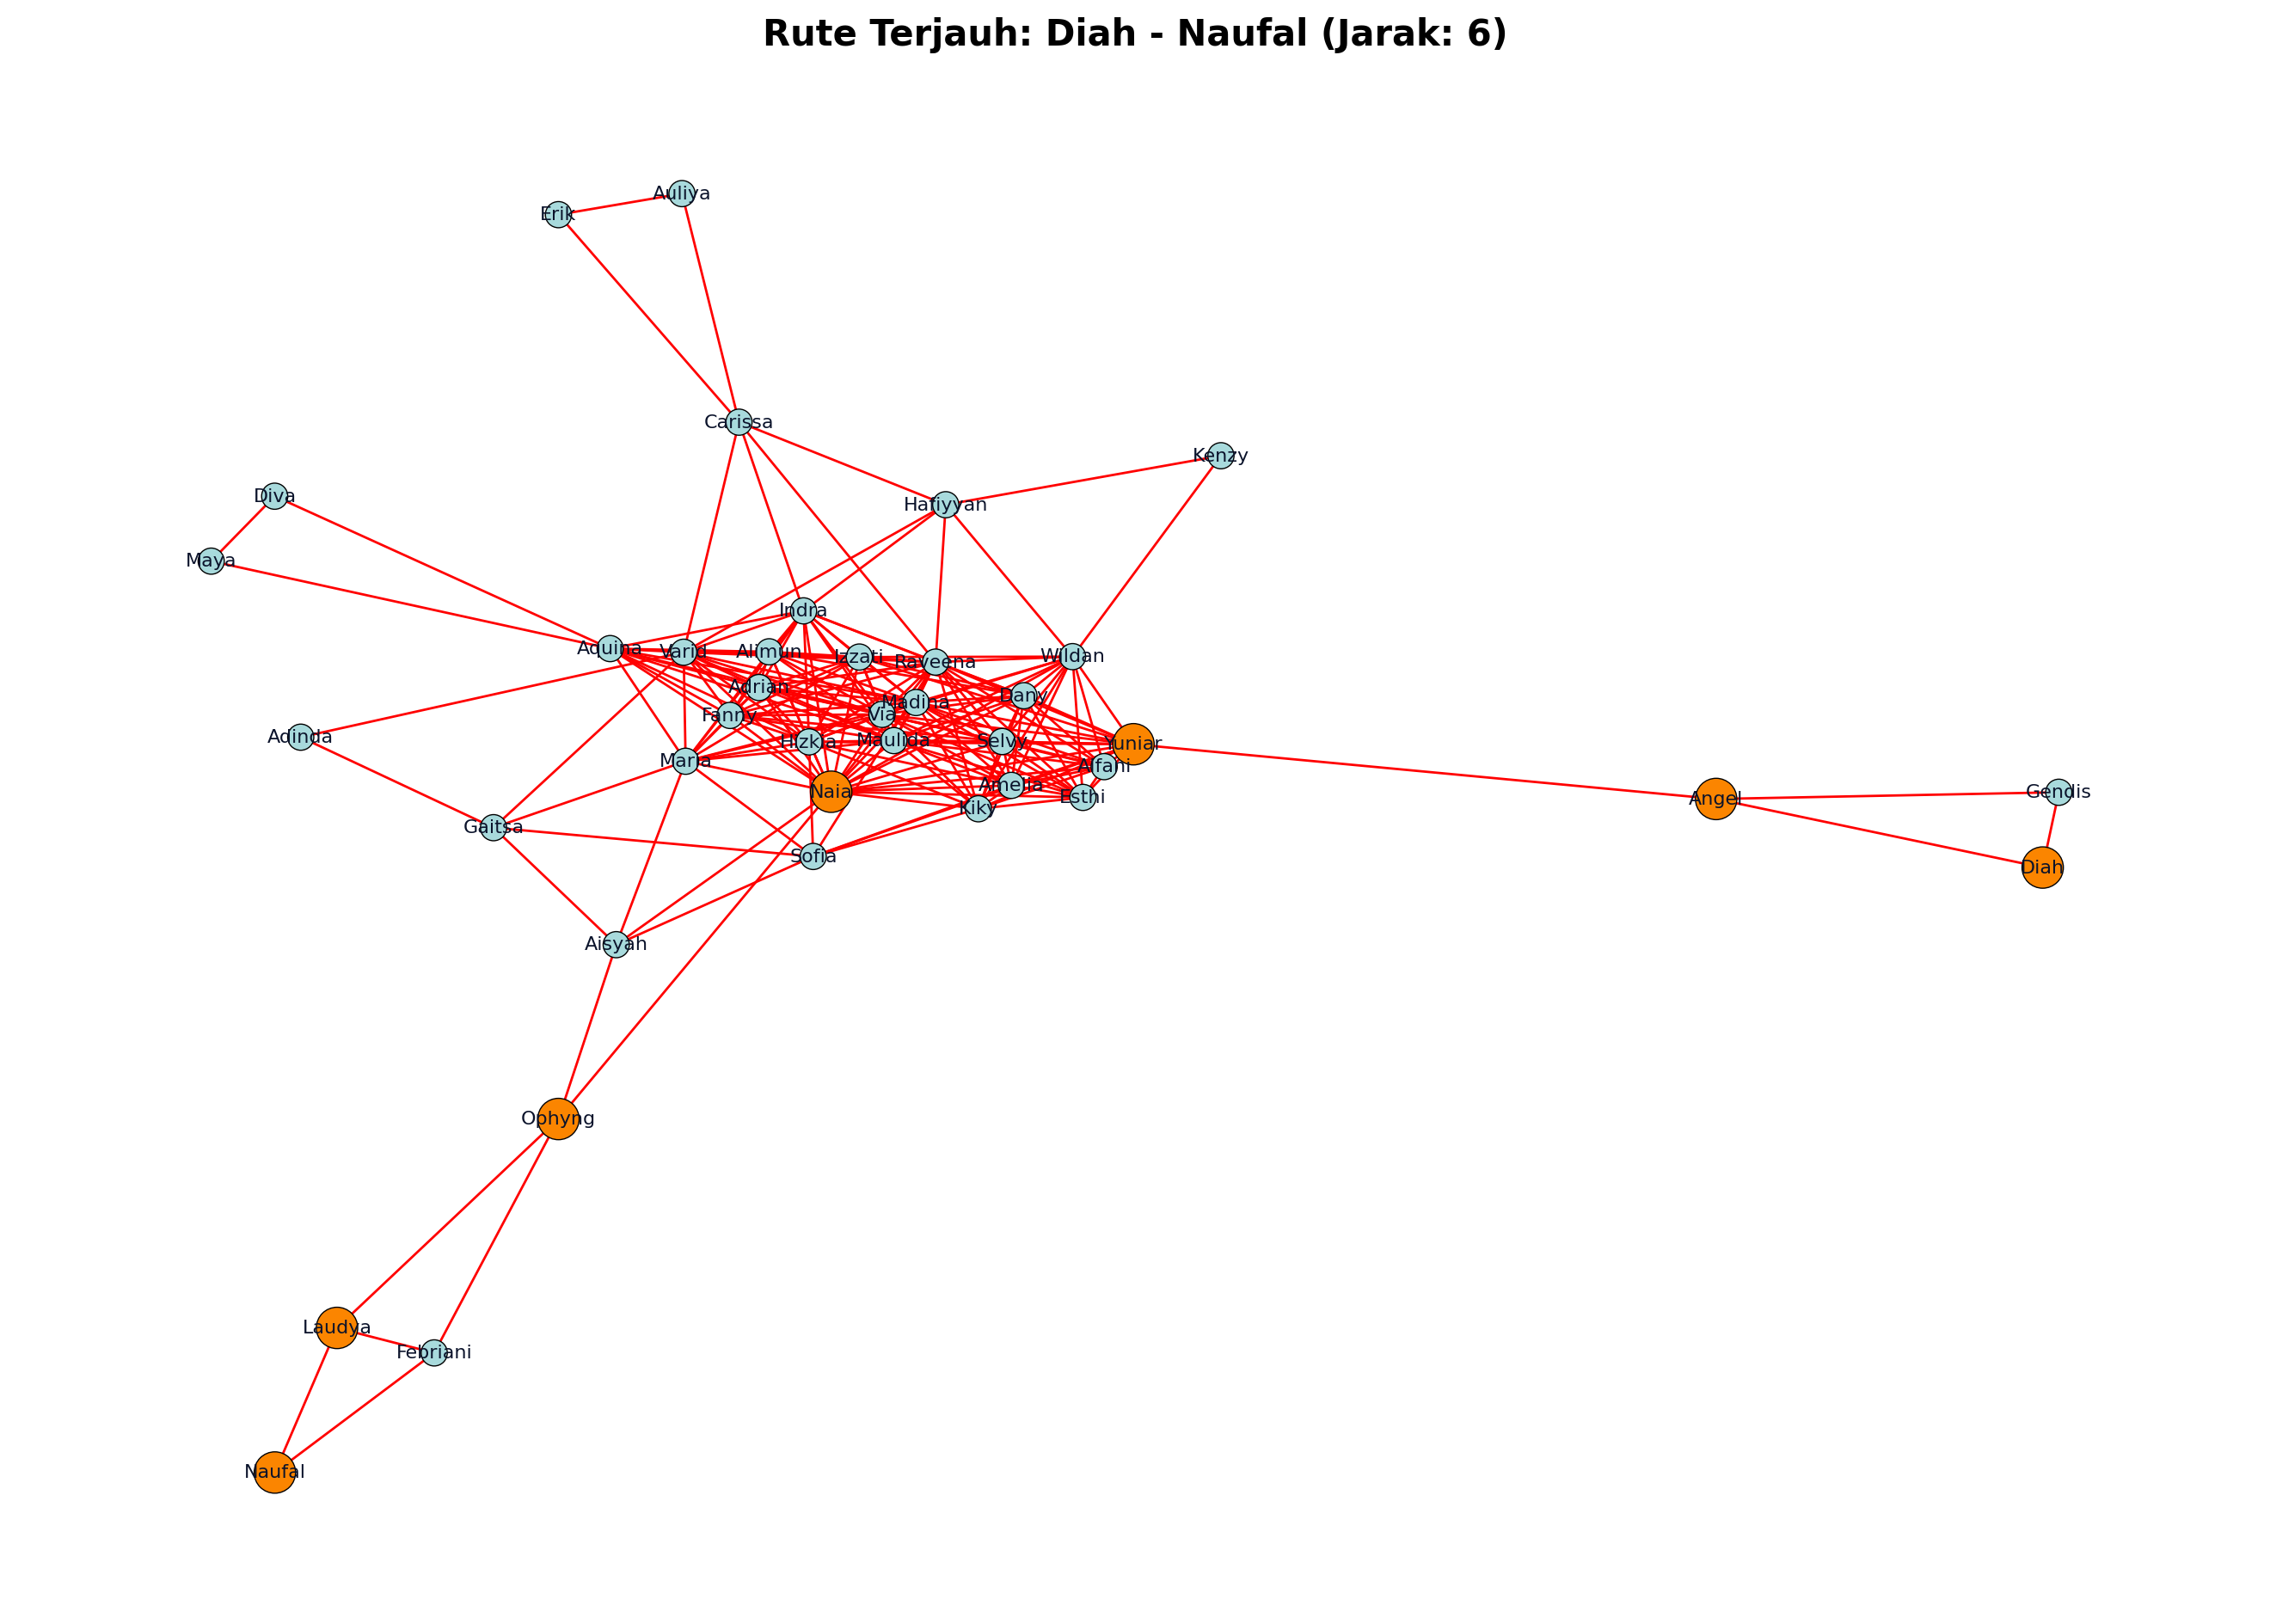

In [8]:
components = list(nx.connected_components(G))
if len(components) > 1:
    largest_comp = max(components, key=len)
    G_largest = G.subgraph(largest_comp).copy()
else:
    G_largest = G

all_paths = dict(nx.all_pairs_shortest_path_length(G_largest))
max_dist = 0
pairs_far = []
for u, targets in all_paths.items():
    for v, d in targets.items():
        if d > max_dist:
            max_dist = d
            pairs_far = [(u, v)]
        elif d == max_dist and (v, u) not in pairs_far:
            pairs_far.append((u, v))

(u_far, v_far) = pairs_far[0]
path = nx.shortest_path(G_largest, u_far, v_far)
path_edges = list(zip(path, path[1:]))

PATH_NODE_COLOR = "#FB8500"
PATH_EDGE_COLOR = "red"

node_colors_list = [
    PATH_NODE_COLOR if node in path else COLOR_CFG["node"]
    for node in G_largest.nodes()
]

node_sizes_list = [
    300 if node in path else 120
    for node in G_largest.nodes()
]

edge_colors_list = [
    PATH_EDGE_COLOR if (u, v) in path_edges or (v, u) in path_edges else COLOR_CFG["edge"]
    for u, v in G_largest.edges()
]

draw_graph(
    G_largest,
    pos,
    title=f"Rute Terjauh: {u_far} - {v_far} (Jarak: {max_dist})",
    node_colors=node_colors_list,
    node_sizes=node_sizes_list,
    edge_colors=edge_colors_list,
    font_color=COLOR_CFG["label"],
    linewidths=0.5,
    edgecolors="black"
)


Visualisasi di atas memperlihatkan dua mahasiswa dengan jarak konektivitas terjauh, yakni Diah dan Naufal, yang terpisah sejauh enam langkah hubungan dalam jaringan sosial kelas. Artinya, agar keduanya bisa saling terhubung, diperlukan beberapa perantara dari teman-teman lain. Agak mengejutkan, ya—padahal mereka berada di kelas yang sama, tapi posisi sosialnya begitu jauh dalam jaringan. Temuan ini menggambarkan bahwa meskipun sebagian besar mahasiswa saling terhubung secara tidak langsung, masih ada “jarak sosial” yang terbentuk secara alami di antara kelompok-kelompok yang lebih rapat.

# 3a. bridge person. nx.betweenness_centrality(G)

In [9]:
betweenness = nx.betweenness_centrality(G)
sorted_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

print("Bridge Person (nilai betweenness tertinggi):")
for i, (nama, bc) in enumerate(sorted_betweenness, start=1):
    print(f"{i}. {nama} -> {bc:.4f}")

Bridge Person (nilai betweenness tertinggi):
1. Naia -> 0.2188
2. Yuniar -> 0.1510
3. Ophyng -> 0.1457
4. Aquina -> 0.0999
5. Angel -> 0.0999
6. Carissa -> 0.0999
7. Varid -> 0.0994
8. Raveena -> 0.0927
9. Wildan -> 0.0470
10. Indra -> 0.0417
11. Madina -> 0.0275
12. Via -> 0.0275
13. Maulida -> 0.0275
14. Maria -> 0.0258
15. Febriani -> 0.0250
16. Laudya -> 0.0250
17. Sofia -> 0.0192
18. Hizkia -> 0.0188
19. Aisyah -> 0.0173
20. Hafiyyan -> 0.0161
21. Izzati -> 0.0139
22. Gaitsa -> 0.0087
23. Dany -> 0.0051
24. Amelia -> 0.0041
25. Kiky -> 0.0041
26. Selvy -> 0.0040
27. Fanny -> 0.0027
28. Adrian -> 0.0027
29. Alimun -> 0.0017
30. Adinda -> 0.0000
31. Alfani -> 0.0000
32. Diah -> 0.0000
33. Kenzy -> 0.0000
34. Auliya -> 0.0000
35. Diva -> 0.0000
36. Erik -> 0.0000
37. Maya -> 0.0000
38. Gendis -> 0.0000
39. Esthi -> 0.0000
40. Naufal -> 0.0000


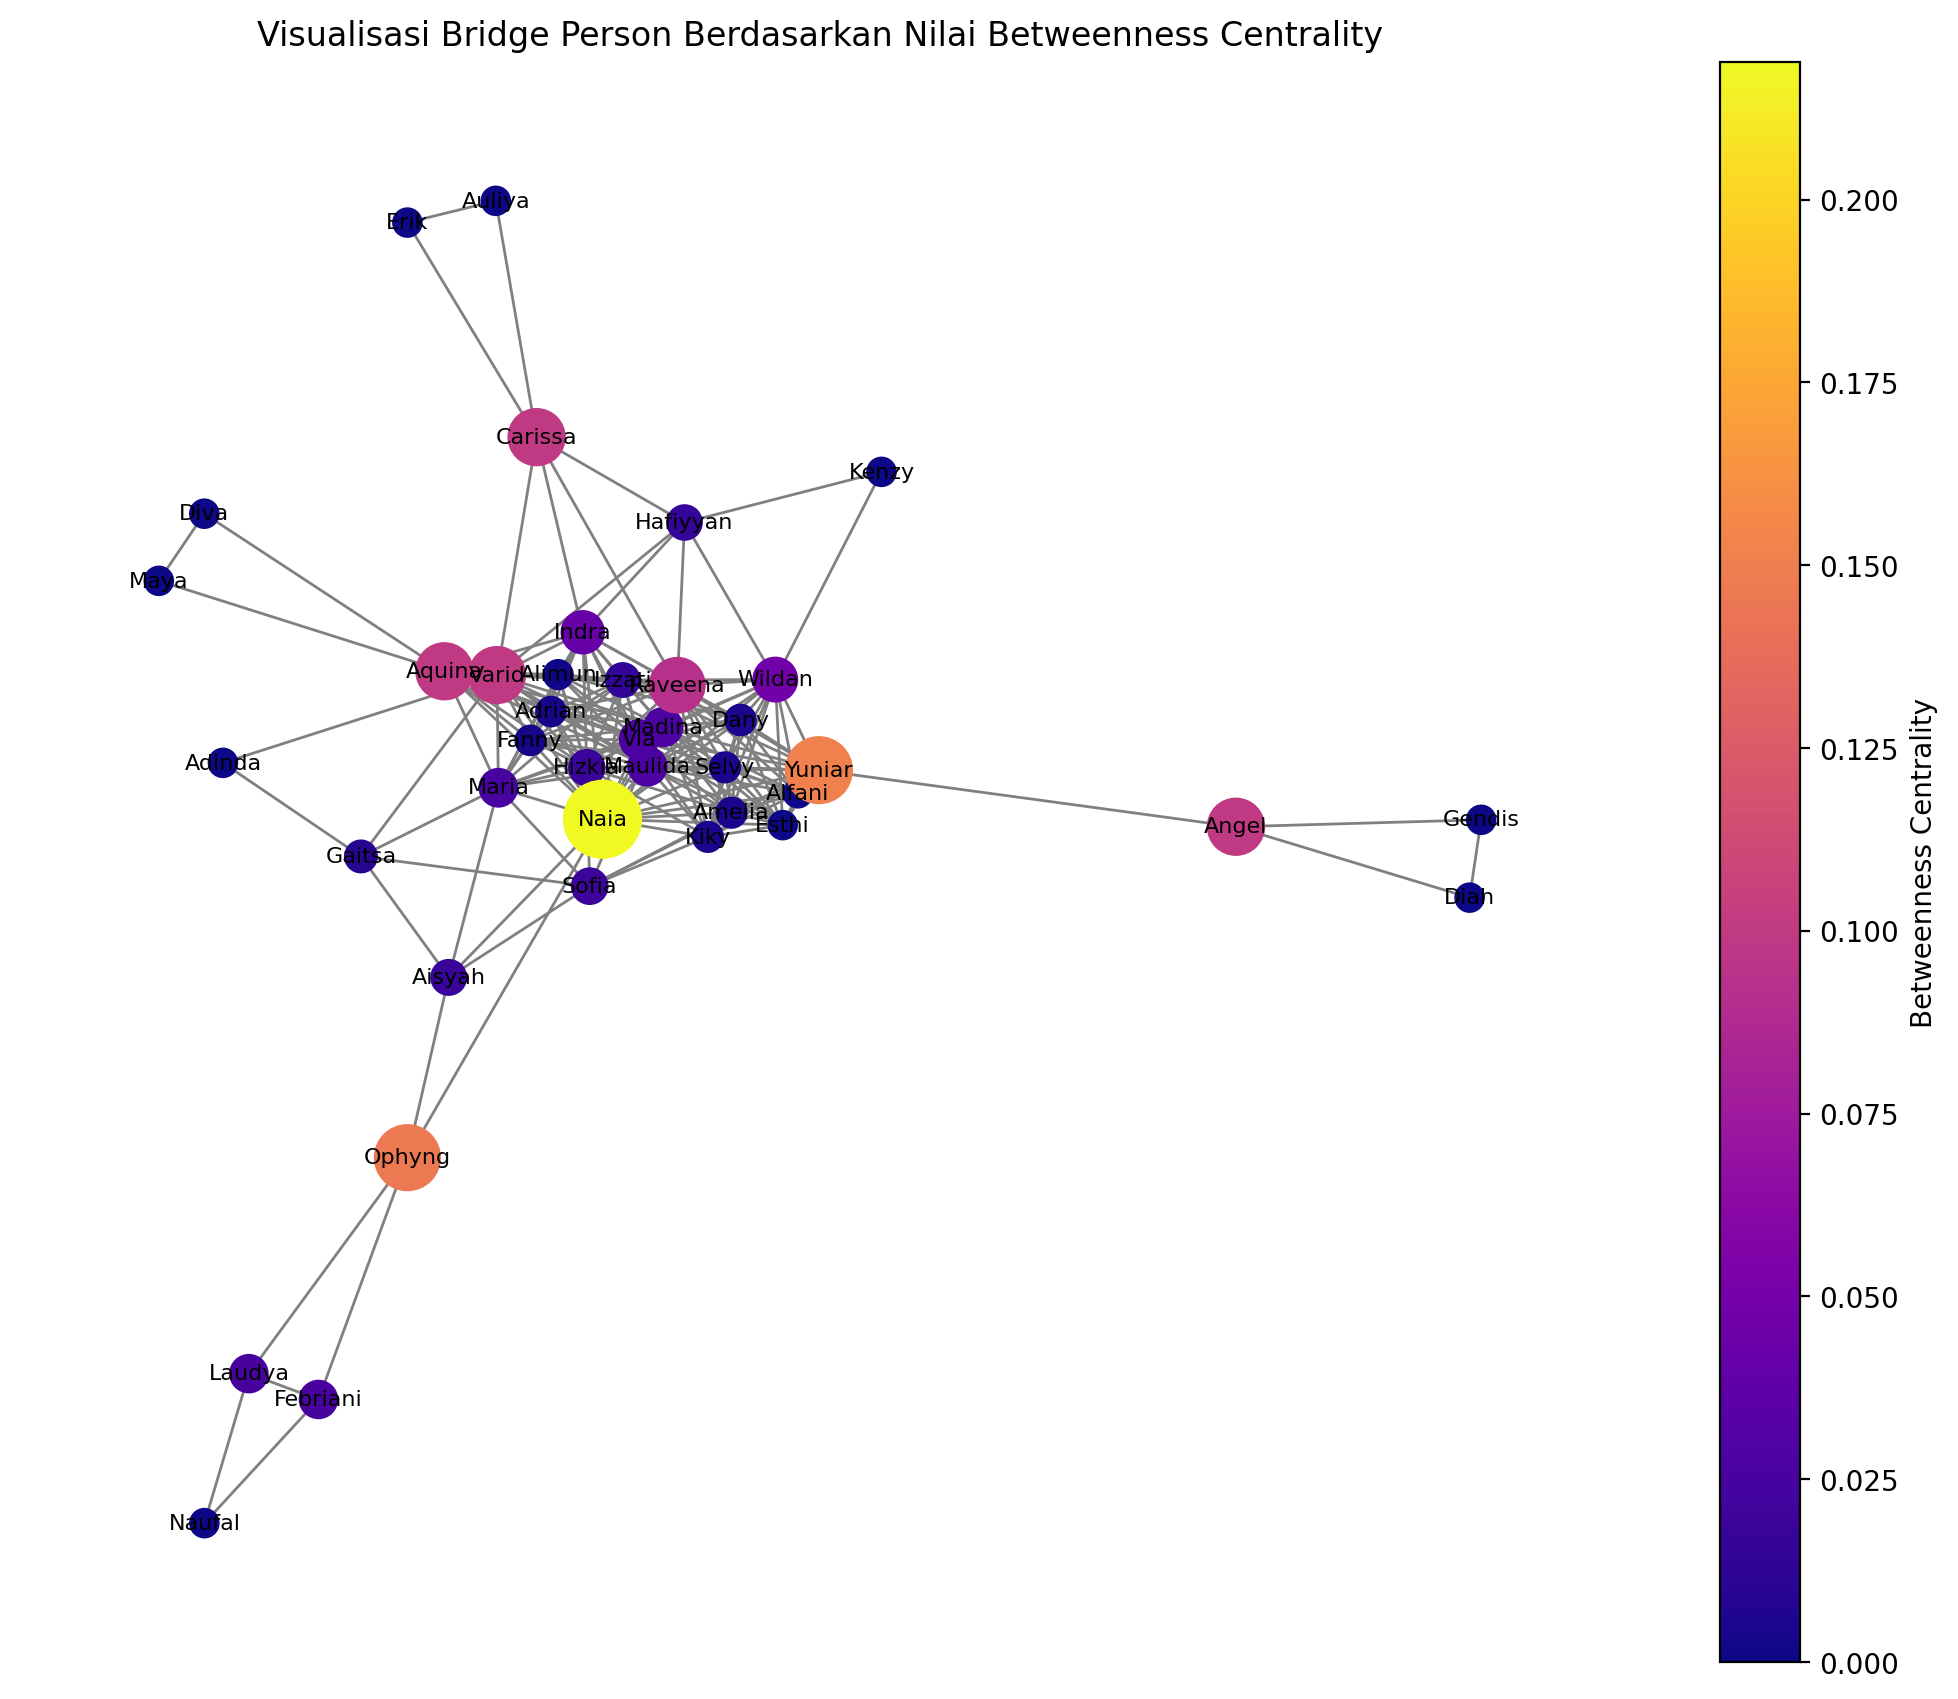

In [10]:
# Visualisasi
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
node_sizes = [3000 * betweenness[n] + 100 for n in G.nodes()]
node_colors = [betweenness[n] for n in G.nodes()]

# Gambar graf
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.plasma,
    font_size=8,
    edge_color="gray",
)

# Tambahkan colorbar untuk menunjukkan skala betweenness
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
plt.colorbar(sm, label="Betweenness Centrality", ax=plt.gca())

plt.title("Visualisasi Bridge Person Berdasarkan Nilai Betweenness Centrality", fontsize=12)
plt.show()

Hasil analisis betweenness centrality menunjukkan bahwa beberapa mahasiswa menempati posisi penting sebagai penghubung utama antar kelompok. Mahasiswa dengan nilai betweenness tertinggi berfungsi seperti “simpul lalu lintas” yang memastikan informasi dan interaksi dapat mengalir di seluruh jaringan sosial kelas. Tanpa mereka, hubungan antar kelompok berpotensi terputus dan komunikasi menjadi lebih terbatas. Dengan demikian, bridge person berperan krusial dalam menjaga integrasi sosial di antara lingkaran pertemanan yang beragam.

# 3b. mencari bridge person dengan koneksi paling sedikit

In [11]:
degree_dict = dict(G.degree())
bridge_only = [(n, betweenness[n], degree_dict[n]) for n in G.nodes() if betweenness[n] > 0]

bridge_koneksi_dikit = sorted(bridge_only, key=lambda x: x[2])

print("\nBridge Person dengan koneksi paling sedikit:")
for nama, bc, deg in bridge_koneksi_dikit:
    print(f"{nama} -> betweenness={bc:.4f}, koneksi={deg}")


Bridge Person dengan koneksi paling sedikit:
Febriani -> betweenness=0.0250, koneksi=3
Angel -> betweenness=0.0999, koneksi=3
Laudya -> betweenness=0.0250, koneksi=3
Ophyng -> betweenness=0.1457, koneksi=4
Aisyah -> betweenness=0.0173, koneksi=5
Gaitsa -> betweenness=0.0087, koneksi=5
Carissa -> betweenness=0.0999, koneksi=6
Hafiyyan -> betweenness=0.0161, koneksi=6
Sofia -> betweenness=0.0192, koneksi=8
Alimun -> betweenness=0.0017, koneksi=13
Aquina -> betweenness=0.0999, koneksi=14
Amelia -> betweenness=0.0041, koneksi=14
Fanny -> betweenness=0.0027, koneksi=14
Adrian -> betweenness=0.0027, koneksi=14
Selvy -> betweenness=0.0040, koneksi=14
Kiky -> betweenness=0.0041, koneksi=14
Maria -> betweenness=0.0258, koneksi=15
Dany -> betweenness=0.0051, koneksi=15
Wildan -> betweenness=0.0470, koneksi=15
Izzati -> betweenness=0.0139, koneksi=16
Indra -> betweenness=0.0417, koneksi=16
Yuniar -> betweenness=0.1510, koneksi=16
Hizkia -> betweenness=0.0188, koneksi=17
Varid -> betweenness=0.09

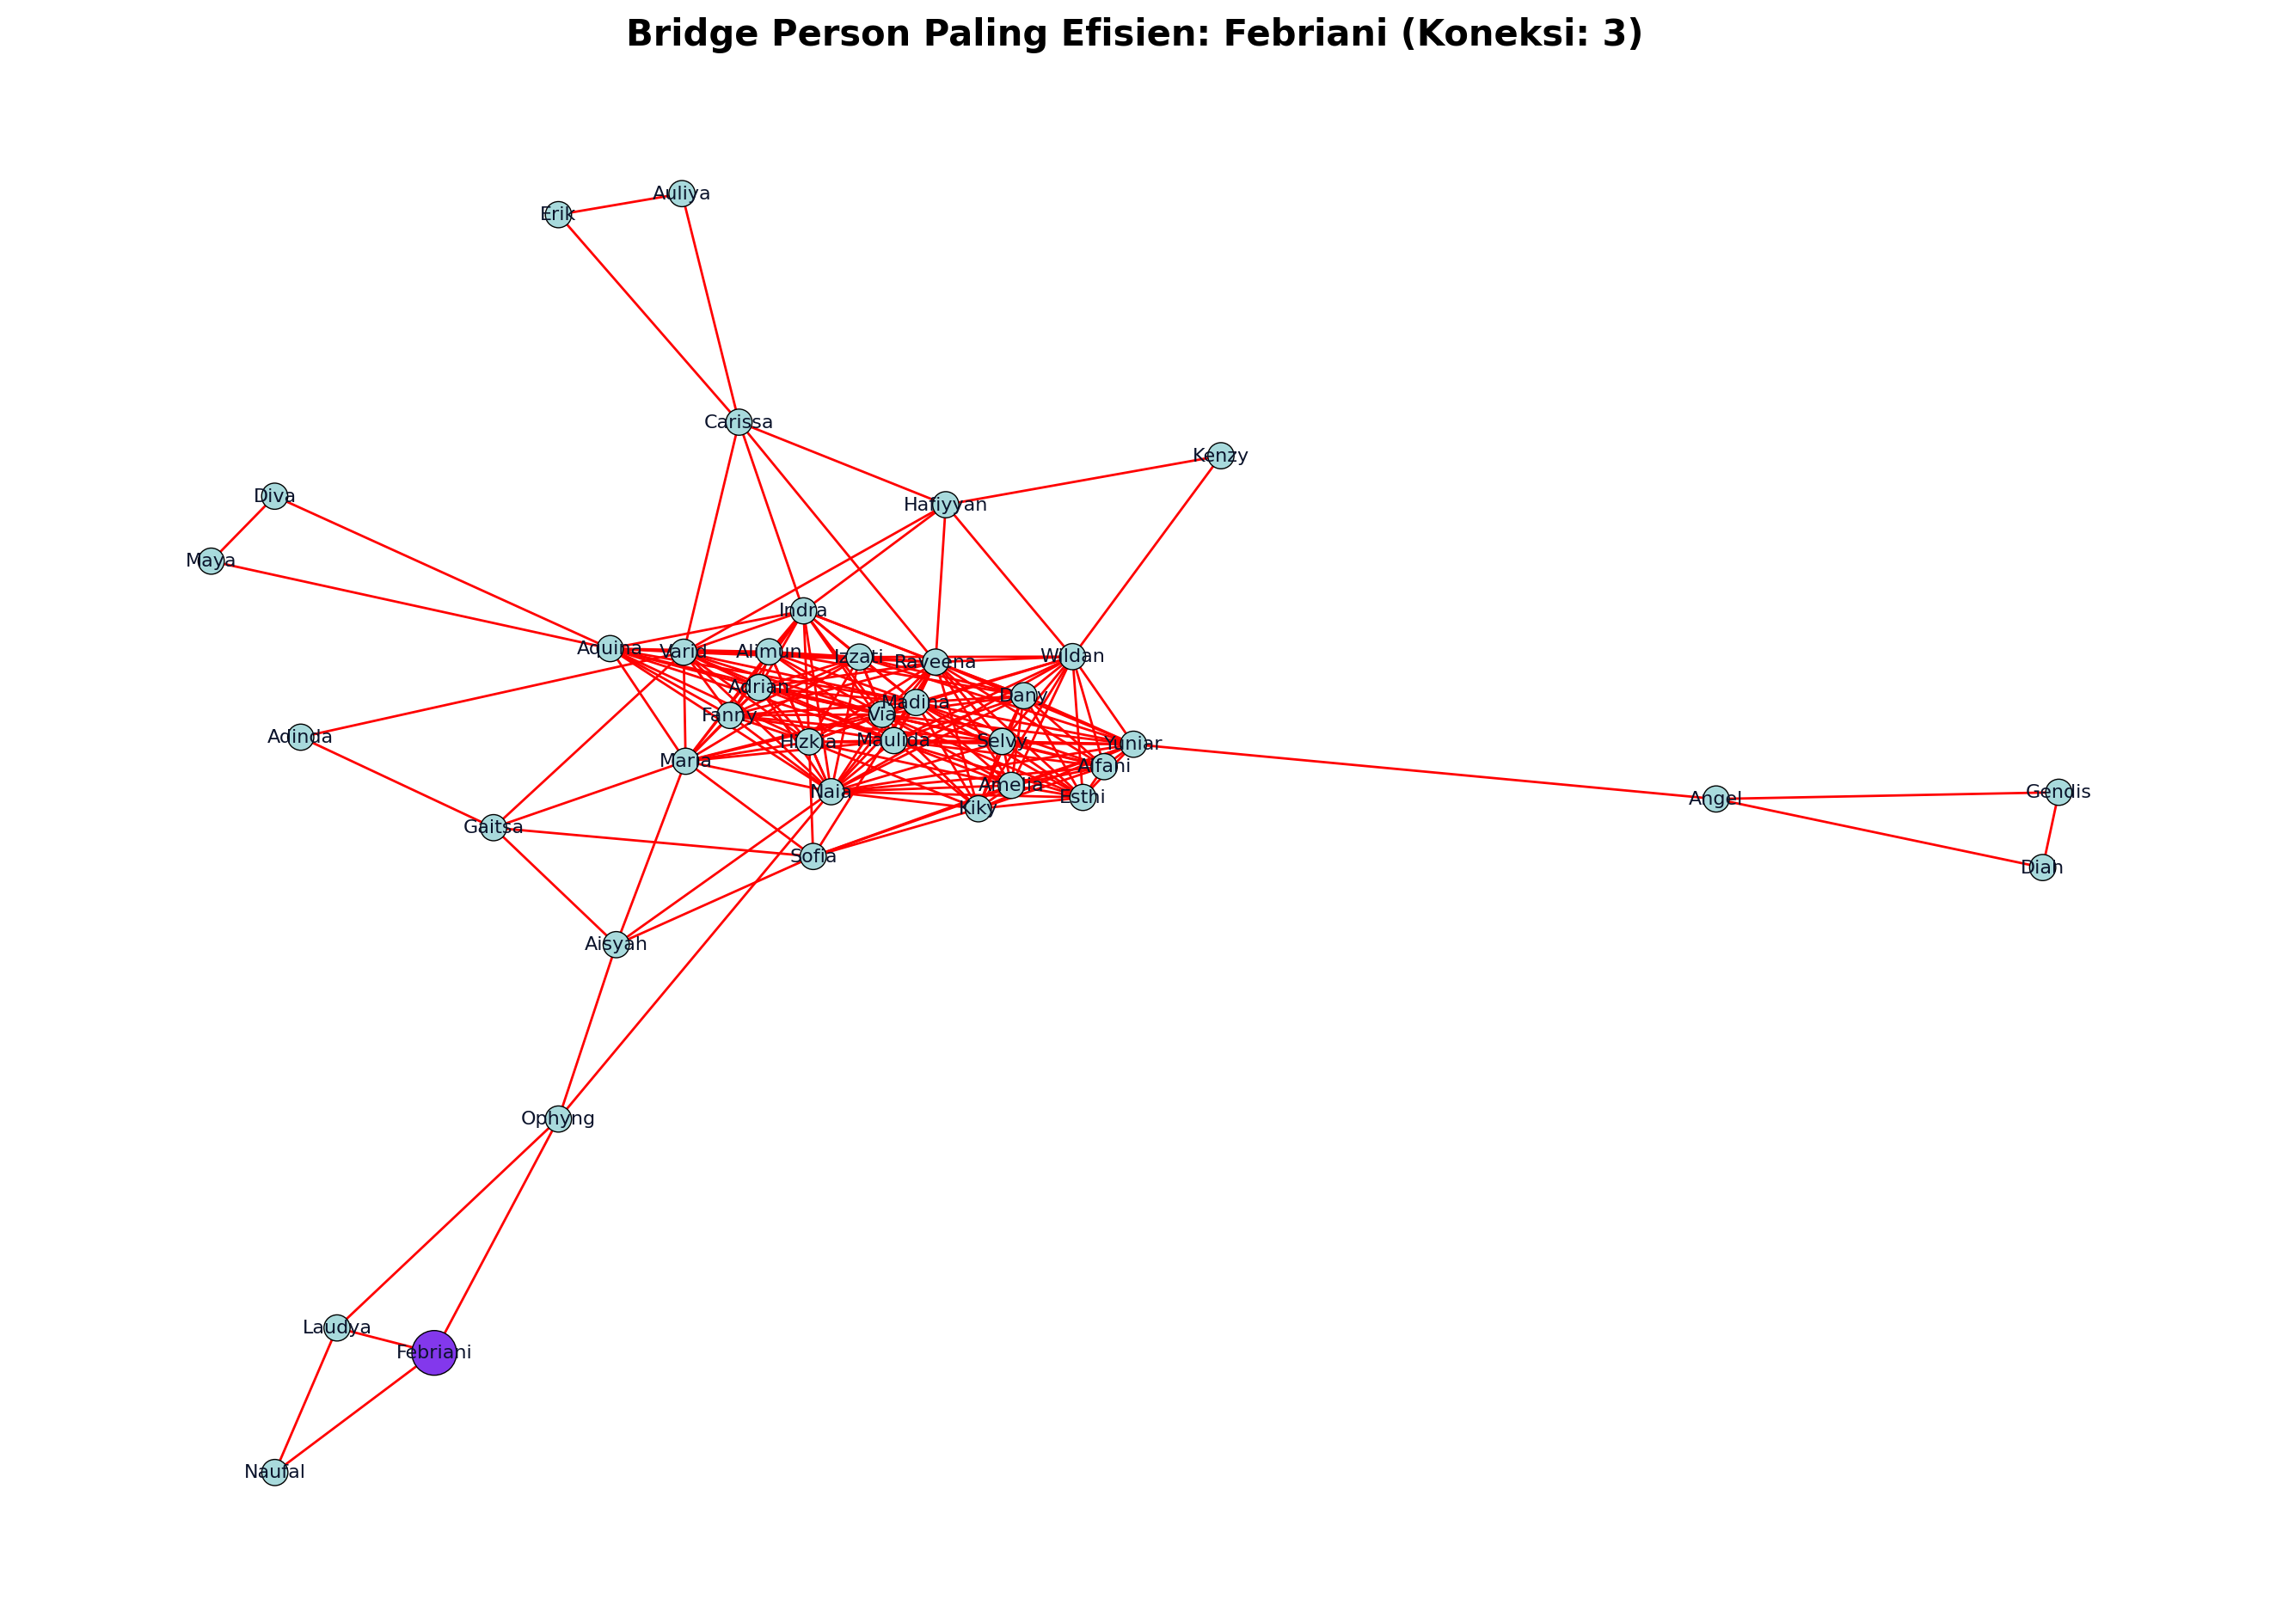

In [12]:
betweenness = nx.betweenness_centrality(G_largest)
degree_dict = dict(G_largest.degree())
bridge_only = [(n, betweenness[n], degree_dict[n]) for n in G_largest.nodes() if betweenness[n] > 0]

bridge_koneksi_dikit = sorted(bridge_only, key=lambda x: x[2])

if bridge_koneksi_dikit:
    target_node_data = bridge_koneksi_dikit[0]
    target_node = target_node_data[0]
    target_degree = target_node_data[2]
    title = f"Bridge Person Paling Efisien: {target_node} (Koneksi: {target_degree})"

    BRIDGE_EFFICIENT_COLOR = "#8338ec"

    node_colors_list = [
        BRIDGE_EFFICIENT_COLOR if node == target_node else COLOR_CFG["node"]
        for node in G_largest.nodes()
    ]

    node_sizes_list = [
        350 if node == target_node else 120
        for node in G_largest.nodes()
    ]

    draw_graph(
        G_largest,
        pos,
        title=title,
        node_colors=node_colors_list,
        node_sizes=node_sizes_list,
        edge_colors=COLOR_CFG["edge"],
        font_color=COLOR_CFG["label"],
        linewidths=0.5,
        edgecolors="black"
    )

Menariknya, terdapat individu yang memiliki jumlah koneksi tidak banyak, namun tetap menempati posisi strategis dalam jaringan. Mereka disebut sebagai bridge person efisien, karena meskipun hanya memiliki sedikit hubungan langsung, keberadaannya menjadi jalur penting yang menghubungkan kelompok berbeda. Fenomena ini memperlihatkan bahwa dalam struktur sosial, pengaruh seseorang tidak semata diukur dari banyaknya relasi, melainkan dari seberapa penting perannya dalam menjembatani koneksi yang lebih luas.

# Percobaan tambahan

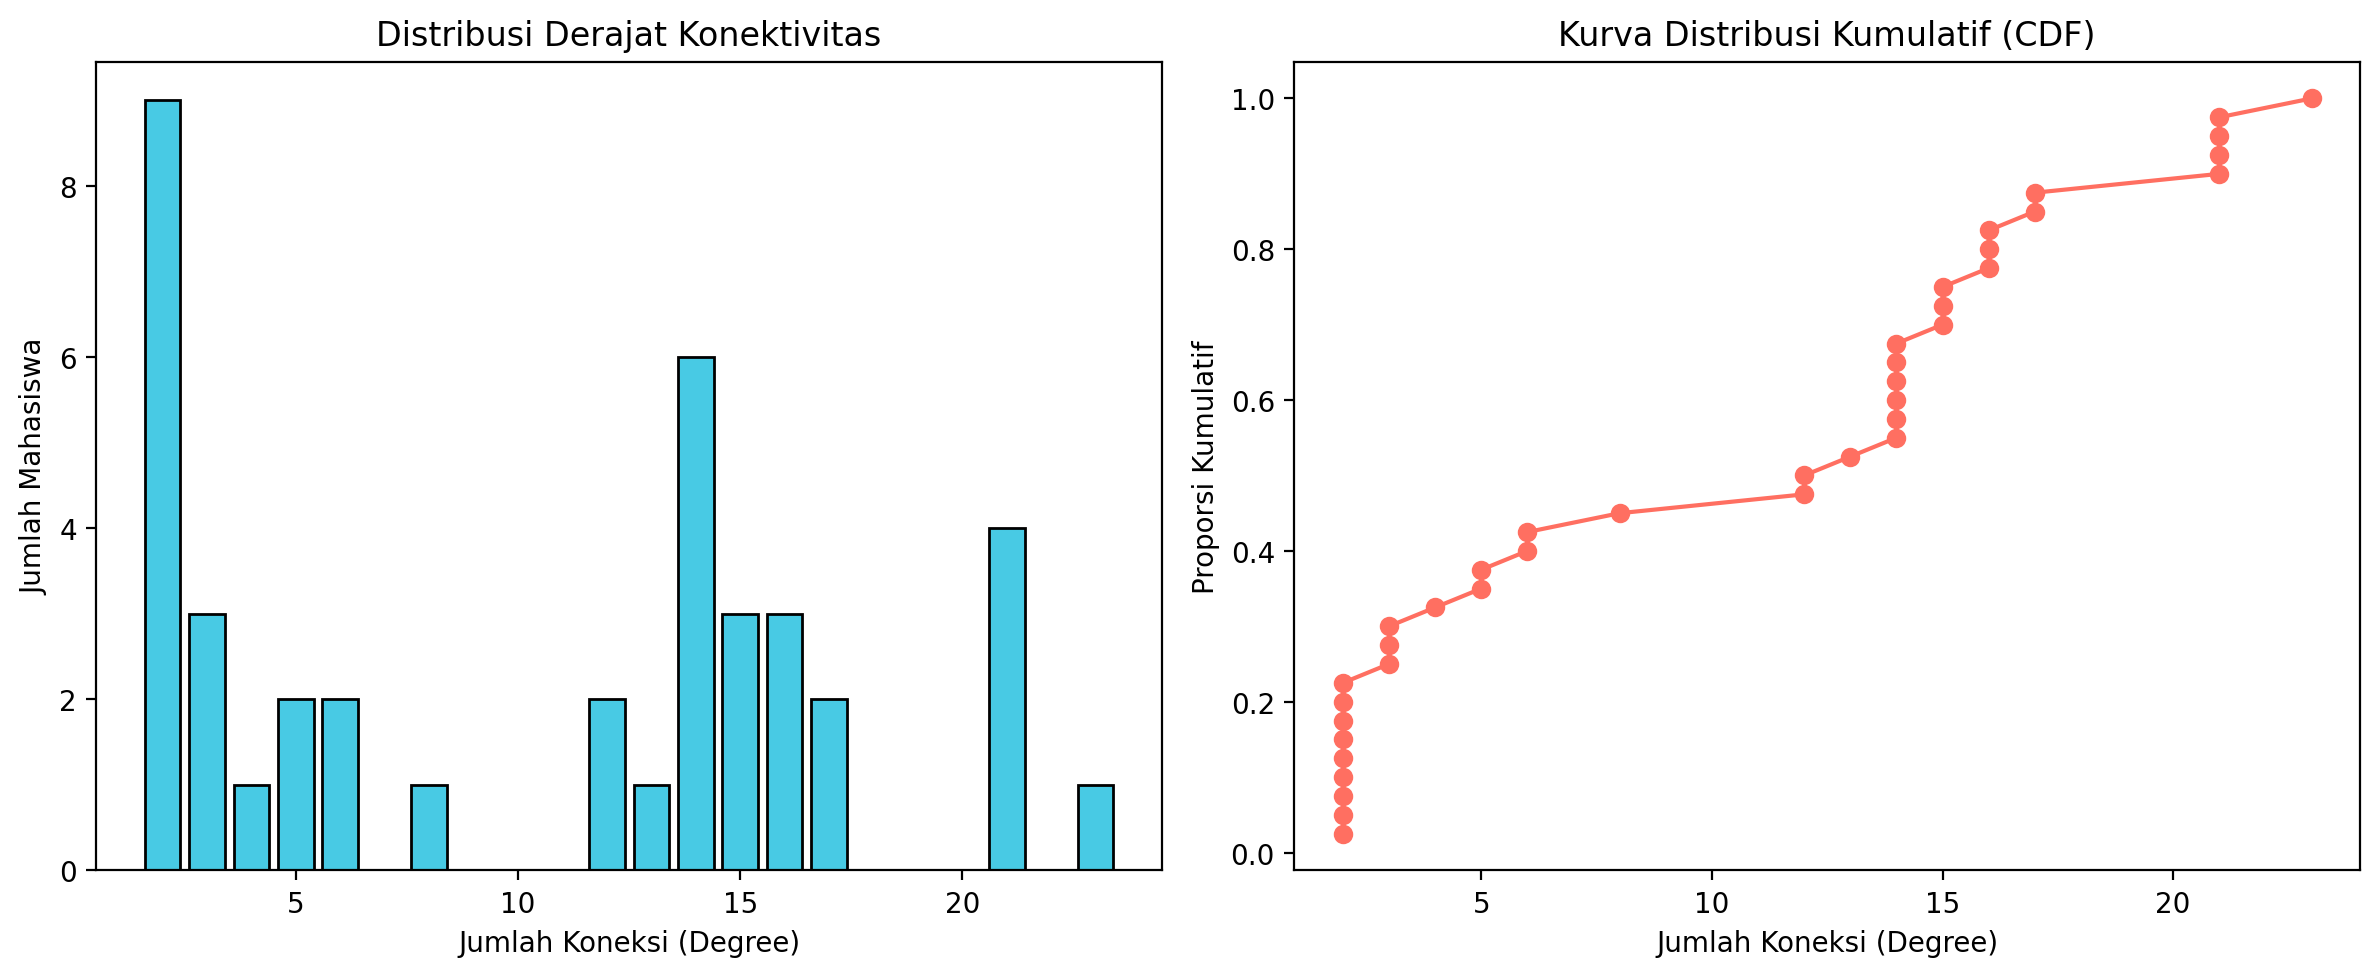

In [13]:
degree_values = [d for n, d in G.degree()]
unique_deg, counts = np.unique(degree_values, return_counts=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(unique_deg, counts, color="#48cae4", edgecolor="black")
plt.xlabel("Jumlah Koneksi (Degree)")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Distribusi Derajat Konektivitas")

plt.subplot(1, 2, 2)
sorted_deg = np.sort(degree_values)
cdf = np.arange(1, len(sorted_deg)+1) / len(sorted_deg)
plt.plot(sorted_deg, cdf, marker='o', linestyle='-', color="#ff6f61")
plt.xlabel("Jumlah Koneksi (Degree)")
plt.ylabel("Proporsi Kumulatif")
plt.title("Kurva Distribusi Kumulatif (CDF)")

plt.tight_layout()
plt.show()

Percobaan tambahan ini dilakukan untuk menganalisis pola sebaran tingkat konektivitas antar mahasiswa dalam jaringan sosial kelas Matematika Diskrit. Tujuan utamanya adalah memahami bagaimana hubungan sosial terdistribusi di seluruh anggota kelas, bukan hanya melihat siapa yang paling banyak memiliki relasi.

Grafik pertama menampilkan distribusi derajat konektivitas, yang memperlihatkan bahwa sebagian besar mahasiswa memiliki jumlah koneksi relatif rendah, sedangkan hanya segelintir individu yang membentuk hubungan lebih luas.

Sementara itu, grafik kedua berupa kurva distribusi kumulatif (CDF) menunjukkan kenaikan bertahap yang menandakan keterhubungan sosial yang tidak sepenuhnya merata, namun tetap saling terjalin di dalam jaringan. Hasil ini mengindikasikan bahwa struktur sosial kelas cenderung stabil dan inklusif, dengan keseimbangan antara kelompok inti dan anggota yang berinteraksi dalam lingkup lebih sempit.